# OLS vs SURE benchmark — hourly gas consumption forecasting

Two models, both structured as **24 hourly equations** (one per Europe/Paris local hour) with the same predictors (Table 1):
- **Hourly OLS**: 24 independent regressions (`models.ols.HourlyOLSModel`).
- **SURE**: the same system estimated jointly by FGLS, exploiting the contemporaneous correlation of residuals across hours of the same day (`models.sure.HourlySUREModel`).

**Train/test split**: train = 2018 → 2024, test = calendar year **2025** (last complete year of the dataset; the partial 2026 remainder is excluded from both, see `models/dataset.py::split_train_test`).

In [1]:
import sys
sys.path.insert(0, "..")

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from models.dataset import load_dataset, build_hourly_equations, split_train_test, target_series
from models.ols import HourlyOLSModel
from models.sure import HourlySUREModel
from models import metrics

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 100

df = load_dataset()
per_hour = build_hourly_equations(df)
train, test = split_train_test(per_hour, test_start="2025-01-01", test_end="2026-01-01")
print(f"train: {len(train[0])} days | test: {len(test[0])} days")

build_hourly_equations: panel balanced over 3055 days (days dropped per hour for imbalance: {0: 10, 1: 14, 2: 5, 3: 13, 4: 14, 5: 14, 6: 14, 7: 14, 8: 14, 9: 14, 10: 14, 11: 14, 12: 14, 13: 14, 14: 14, 15: 14, 16: 14, 17: 14, 18: 14, 19: 14, 20: 14, 21: 13, 22: 13, 23: 13})
train: 2541 days | test: 364 days


In [2]:
ols = HourlyOLSModel().fit(train)
sure = HourlySUREModel().fit(train)

y_train, y_test = target_series(train), target_series(test)
preds = {
    ("OLS", "train"): ols.predict(train), ("OLS", "test"): ols.predict(test),
    ("SURE", "train"): sure.predict(train), ("SURE", "test"): sure.predict(test),
}

## 1. Overall metrics (train / test)

In [3]:
rows = []
for model_name in ("OLS", "SURE"):
    for split_name, y_true in (("train", y_train), ("test", y_test)):
        m = metrics.evaluate_overall(y_true, preds[(model_name, split_name)])
        rows.append({"modele": model_name, "split": split_name, **m})

summary = pd.DataFrame(rows).set_index(["modele", "split"])[["rmse", "mape", "mae", "n"]].round(2)
summary

rmse   mape       mae      n
modele split                                  
OLS    train   6163.34  11.66   4850.68  60984
       test   11335.72  30.21  10080.64   8736
SURE   train   6446.91  11.84   4991.03  60984
       test   11484.49  30.35  10074.01   8736

In [4]:
test_rmse_ols = summary.loc[("OLS", "test"), "rmse"]
test_rmse_sure = summary.loc[("SURE", "test"), "rmse"]
winner = "SURE" if test_rmse_sure < test_rmse_ols else "OLS"
gap_pct = abs(test_rmse_sure - test_rmse_ols) / test_rmse_ols * 100
print(f"On the 2025 test, {winner} has the lowest RMSE "
      f"(OLS={test_rmse_ols:.0f} MW, SURE={test_rmse_sure:.0f} MW, gap={gap_pct:.1f}%).")

On the 2025 test, OLS has the lowest RMSE (OLS=11336 MW, SURE=11484 MW, gap=1.3%).


## 2. RMSE by local hour (2025 test)
Where each model errs the most across the day (e.g. morning peak hours vs night trough).

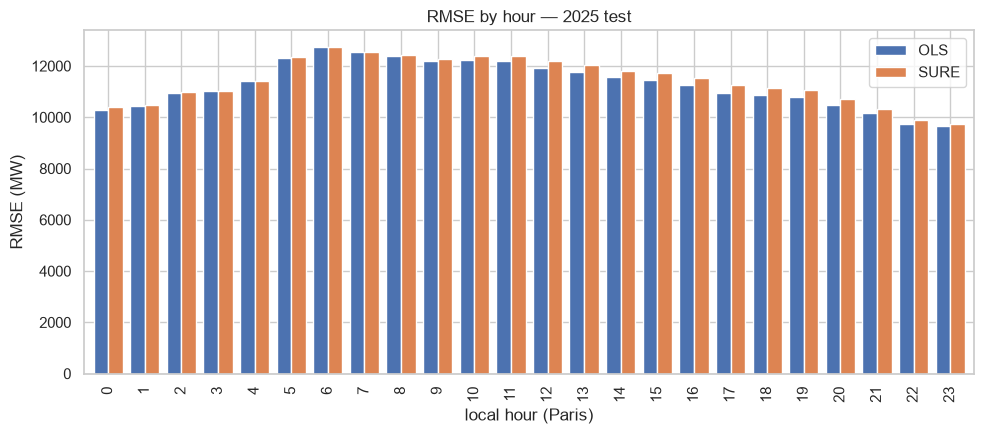

In [5]:
hourly_rmse = pd.DataFrame({
    "OLS": metrics.evaluate_hourly(y_test, preds[("OLS", "test")])["rmse"],
    "SURE": metrics.evaluate_hourly(y_test, preds[("SURE", "test")])["rmse"],
})

fig, ax = plt.subplots(figsize=(10, 4.5))
hourly_rmse.plot(kind="bar", ax=ax, width=0.8)
ax.set_xlabel("local hour (Paris)")
ax.set_ylabel("RMSE (MW)")
ax.set_title("RMSE by hour — 2025 test")
plt.tight_layout()
plt.show()

## 3. Predictions vs actual — winter window (2 weeks, 2025 test)
High heating-demand period: this is where the thermal block (X1/X2) works hardest.

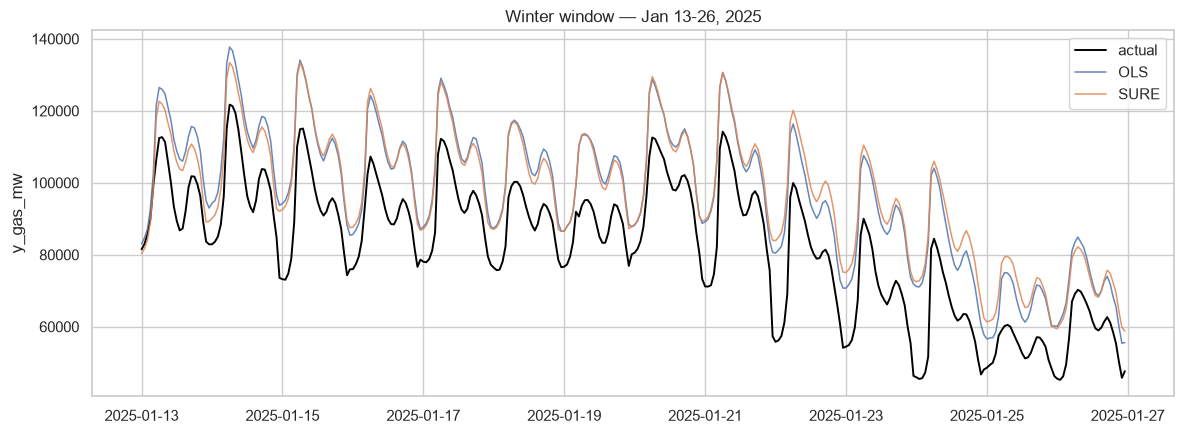

In [6]:
def plot_window(start, end, title):
    actual = metrics.combine_hourly(y_test).loc[start:end]
    ols_line = metrics.combine_hourly(preds[("OLS", "test")]).loc[start:end]
    sure_line = metrics.combine_hourly(preds[("SURE", "test")]).loc[start:end]

    fig, ax = plt.subplots(figsize=(12, 4.5))
    ax.plot(actual.index, actual.values, label="actual", color="black", linewidth=1.4)
    ax.plot(ols_line.index, ols_line.values, label="OLS", linewidth=1.1, alpha=0.85)
    ax.plot(sure_line.index, sure_line.values, label="SURE", linewidth=1.1, alpha=0.85)
    ax.set_ylabel("y_gas_mw")
    ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    plt.show()

plot_window("2025-01-13", "2025-01-26", "Winter window — Jan 13-26, 2025")

## 4. Predictions vs actual — summer window (2 weeks, 2025 test)
Non-heating period: consumption should be low and flat, driven mostly by the base load (`beta_0`) and calendar effects.

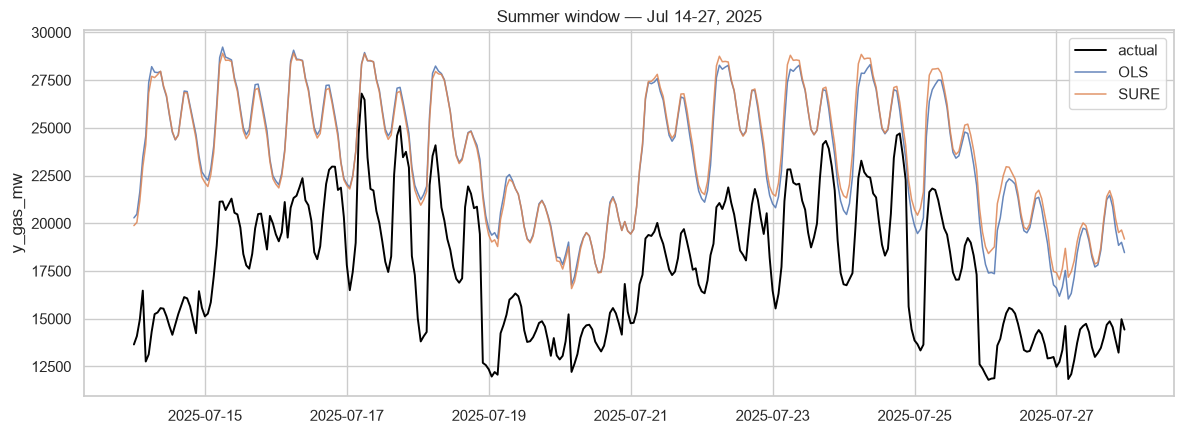

In [7]:
plot_window("2025-07-14", "2025-07-27", "Summer window — Jul 14-27, 2025")